In [68]:
import numpy as np
import matplotlib.pyplot as plt

In [112]:
house_size_x = np.array([
750,850,950,1050,1150,
1250,1350,1450,1550,1650,
1750,1850,1950,2050,2150,
2250,2350,2450,2550,2650
])

price_in_usd_y = np.array([
150,170,190,210,230,
250,268,289,311,328,
348,367,389,407,429,
447,468,488,507,529
])
w=0.15
b=20

In [113]:
def cost(x,y,w,b):
    summation=0
    m=x.shape[0]
    for i in range(m):
        y_cap=w*x[i]+b
        summation+=(y_cap-y[i])**2
        J=1/(2*m)*summation
    return J

In [114]:
def differentiate(x,y,w,b):
    sum_w=0
    sum_b=0
    m=x.shape[0]
    for i in range(0,m):
        y_cap=w*x[i]+b
        sum_w+=(y_cap-y[i])*x[i]
        sum_b+=(y_cap-y[i])
    dj_dw=(1/m)*sum_w
    dj_db=(1/m)*sum_b
    return dj_dw,dj_db

In [115]:
def GD(w,b,alpha):
    a,c=differentiate(house_size_x,price_in_usd_y,w,b)
    w=w-alpha*a
    b=b-alpha*c
    return w,b

In [196]:
l=[]
def main():
    house_size_x=np.array([1000,1500,2000])
    price_in_usd_y=np.array([200,300,400])
    w=0.15
    b=20
    alpha=0.000000009
    iteration=50
    J_wb=cost(house_size_x,price_in_usd_y,w,b)
    for i in range(iteration):
        new_w,new_b=GD(w,b,alpha)
        w=new_w
        b=new_b
        new_cost=cost(house_size_x,price_in_usd_y,w,b)
        l.append(new_cost)
    
        if(new_cost<J_wb):
            J_wb=new_cost
        else:
            return f'Cost increased in iteration {iteration}! Gradient Descent is diverging.Try reducing the learning rate (alpha).'
    return J_wb,w,b

In [197]:
main() #Change the slope(w) value and no. of iterations

(np.float64(87.55303386146065),
 np.float64(0.17977321592348294),
 np.float64(20.00001483089898))

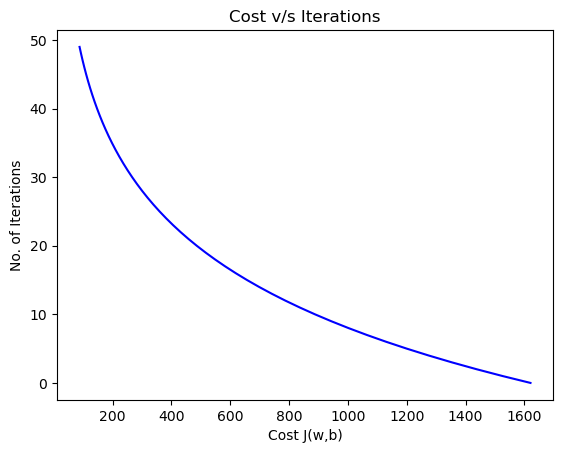

In [198]:
iteration=50 #This number is same as the number taken in the main() function iteration!
import matplotlib.pyplot as plt
plt.plot(l,range(len(l)),c='b')
plt.title('Cost v/s Iterations')
plt.xlabel("Cost J(w,b)")
plt.ylabel('No. of Iterations')
plt.show()

In [199]:
v,t,y=main()

In [200]:
m=house_size_x.shape[0]
l=[]
for i in range(0,m):
    y_cap=t*house_size_x[i]+b
    l.append(y_cap)
for i in range(0,len(l)):
    print(f'House {i+1}: Actual Cost: ${price_in_usd_y[i]}K | Predicted Cost: ${l[i]:.2f}K\n')

House 1: Actual Cost: $150K | Predicted Cost: $154.83K

House 2: Actual Cost: $170K | Predicted Cost: $172.81K

House 3: Actual Cost: $190K | Predicted Cost: $190.78K

House 4: Actual Cost: $210K | Predicted Cost: $208.76K

House 5: Actual Cost: $230K | Predicted Cost: $226.74K

House 6: Actual Cost: $250K | Predicted Cost: $244.72K

House 7: Actual Cost: $268K | Predicted Cost: $262.69K

House 8: Actual Cost: $289K | Predicted Cost: $280.67K

House 9: Actual Cost: $311K | Predicted Cost: $298.65K

House 10: Actual Cost: $328K | Predicted Cost: $316.63K

House 11: Actual Cost: $348K | Predicted Cost: $334.60K

House 12: Actual Cost: $367K | Predicted Cost: $352.58K

House 13: Actual Cost: $389K | Predicted Cost: $370.56K

House 14: Actual Cost: $407K | Predicted Cost: $388.54K

House 15: Actual Cost: $429K | Predicted Cost: $406.51K

House 16: Actual Cost: $447K | Predicted Cost: $424.49K

House 17: Actual Cost: $468K | Predicted Cost: $442.47K

House 18: Actual Cost: $488K | Predicted

In [201]:
s=float(input("Enter the Size of House Sq feet: "))
expected=t*s+b
print(f'Expected Price of the house is ${expected:.2f}K')

Enter the Size of House Sq feet:  1500


Expected Price for the house is $289.66K
